In [1]:
# Compare RMSE curves for DQN and MFI on simulated response data (EXP027).
# EAP and MLE are drawn on separate panels.
#
# Auto-detects every summary CSV of the form
#   summary_uncor_{BANK_ID}_DQN_{METHOD}_gamma_{GAMMA}.csv
# and pairs it with the matching Python-side MFI baseline
#   summary_uncor_{BANK_ID}_MFI_{METHOD}_python.csv
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "data").is_dir() and (root / "EXP027").is_dir():
            return root
    raise FileNotFoundError("Run this notebook inside the repository.")


def rmse_at(data: pd.DataFrame, steps: list[int]) -> list[float]:
    integer_steps = data["step"].round().astype(int)
    return [
        float(data.loc[integer_steps == step, "RMSE"].iloc[0])
        if (integer_steps == step).any()
        else float("nan")
        for step in steps
    ]


ROOT = find_project_root()
EXP027_RESULTS = ROOT / "EXP027" / "results"

BANK_ID = 1
TEST_LENGTH = 40
KEY_STEPS = [10, 20, 30, 40]
# Methods to plot separately, in order.
METHODS = ["EAP_unif", "MLE"]

print(f"Project root : {ROOT}")
print(f"Results dir  : {EXP027_RESULTS}")
print(f"Bank ID      : {BANK_ID}")
print(f"Methods      : {METHODS}")

Project root : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Results dir  : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results
Bank ID      : 1
Methods      : ['EAP_unif', 'MLE']


In [2]:
# Discover every DQN gamma per method and its MFI pair.
dqn_pattern = re.compile(
    rf"summary_uncor_{BANK_ID}_DQN_(?P<method>.+?)_gamma_(?P<gamma>.+?)\.csv$"
)

runs: dict[str, dict] = {method: {"gammas": {}, "mfi": None} for method in METHODS}
for path in sorted(EXP027_RESULTS.glob(f"summary_uncor_{BANK_ID}_DQN_*_gamma_*.csv")):
    match = dqn_pattern.match(path.name)
    if match is None:
        continue
    method = match.group("method")
    gamma = match.group("gamma")
    if method not in runs:
        runs[method] = {"gammas": {}, "mfi": None}
    runs[method]["gammas"][gamma] = pd.read_csv(path)

for method, run in runs.items():
    mfi_path = EXP027_RESULTS / f"summary_uncor_{BANK_ID}_MFI_{method}_python.csv"
    if mfi_path.exists():
        run["mfi"] = pd.read_csv(mfi_path)

# Prune methods that have neither DQN nor MFI (nothing to plot).
runs = {
    method: run
    for method, run in runs.items()
    if run["gammas"] or run["mfi"] is not None
}

if not runs:
    raise FileNotFoundError(
        f"No matching DQN / MFI summary CSVs under {EXP027_RESULTS} "
        f"for bank {BANK_ID}."
    )

for method, run in runs.items():
    gammas_str = str(sorted(run["gammas"])) if run["gammas"] else "[]"
    mfi_str = "yes" if run["mfi"] is not None else "NO"
    print(f"  method={method:8s}  gammas={gammas_str:<20}  mfi={mfi_str}")

  method=EAP_unif  gammas=['0.1']               mfi=yes
  method=MLE       gammas=['0.1', '0.9']        mfi=yes


In [3]:
# Shared draw helper. One panel per method; MFI as a dashed reference; each DQN
# gamma as its own colored solid line.
cmap = plt.get_cmap("tab10")


def draw_panel(axis, method: str, run: dict) -> None:
    if run["mfi"] is not None:
        mfi = run["mfi"]
        axis.plot(
            mfi["step"],
            mfi["RMSE"],
            label=f"MFI ({method})",
            color="steelblue",
            linestyle="--",
            linewidth=1.8,
        )
    for i, gamma in enumerate(sorted(run["gammas"])):
        curve = run["gammas"][gamma]
        axis.plot(
            curve["step"],
            curve["RMSE"],
            label=f"DQN ({method}, gamma={gamma})",
            color=cmap(i),
            linewidth=1.8,
        )
    for step in KEY_STEPS:
        axis.axvline(step, color="black", linewidth=0.6, linestyle=":", alpha=0.4)
    axis.set_xlabel("Step", fontsize=13)
    axis.set_ylabel("RMSE", fontsize=13)
    axis.grid(True, linestyle="--", alpha=0.4)
    axis.xaxis.set_major_locator(mticker.MultipleLocator(5))
    axis.set_xlim(1, TEST_LENGTH)
    axis.set_ylim(bottom=0)
    axis.legend(fontsize=10)

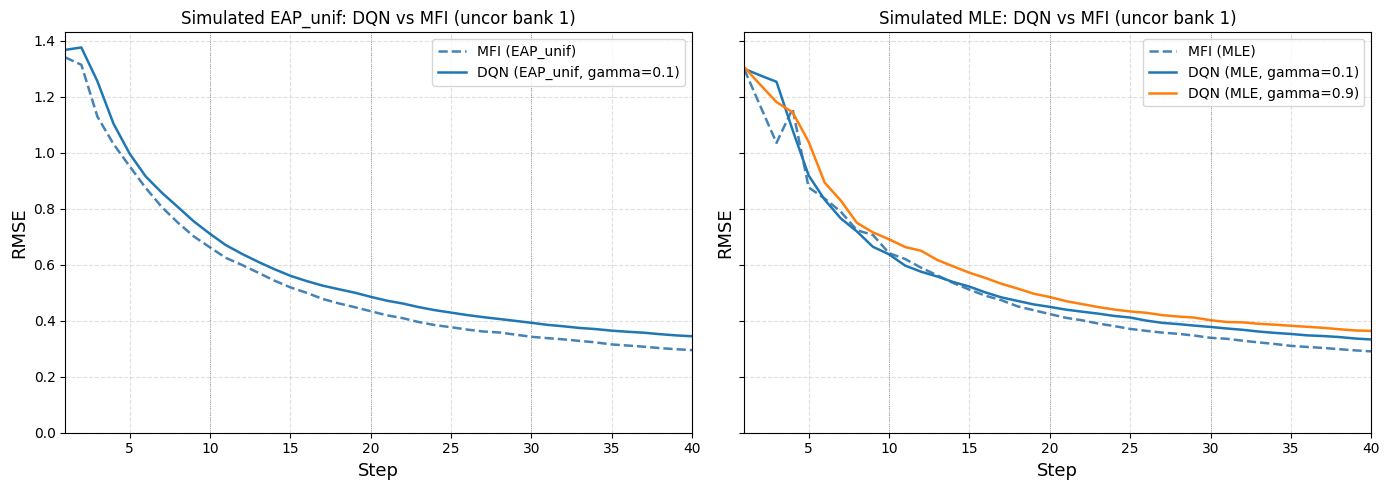

Saved combined figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/rmse_comparison_sim_uncor_1_EAP_MLE.png


In [4]:
# Combined figure: EAP and MLE side by side. sharey=True since both are on the
# same simulated bank scale.
n_panels = len(runs)
figure, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5), squeeze=False, sharey=True)
for axis, (method, run) in zip(axes[0], runs.items()):
    draw_panel(axis, method, run)
    axis.set_title(
        f"Simulated {method}: DQN vs MFI (uncor bank {BANK_ID})",
        fontsize=12,
    )

figure.tight_layout()
EXP027_RESULTS.mkdir(parents=True, exist_ok=True)
combined_path = EXP027_RESULTS / f"rmse_comparison_sim_uncor_{BANK_ID}_EAP_MLE.png"
figure.savefig(combined_path, dpi=150)
plt.show()
print(f"Saved combined figure to: {combined_path}")

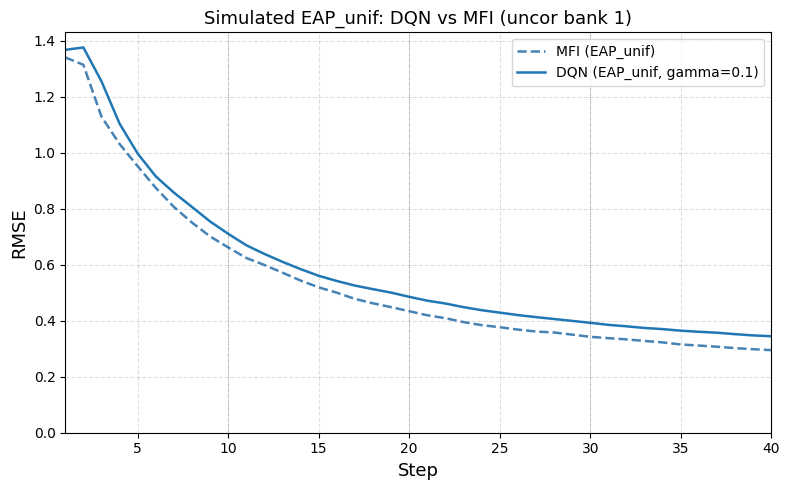

Saved to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/rmse_comparison_sim_uncor_1_EAP_unif.png


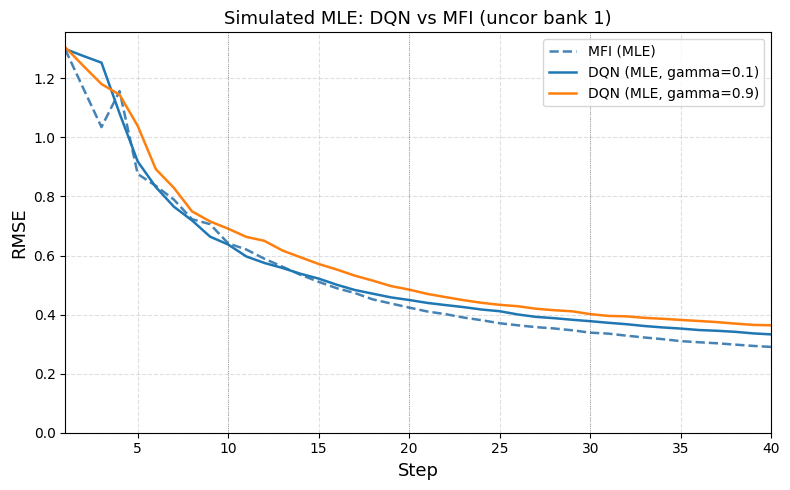

Saved to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/rmse_comparison_sim_uncor_1_MLE.png


In [5]:
# Save each method as its own PNG.
for method, run in runs.items():
    figure, axis = plt.subplots(figsize=(8, 5))
    draw_panel(axis, method, run)
    axis.set_title(
        f"Simulated {method}: DQN vs MFI (uncor bank {BANK_ID})",
        fontsize=13,
    )
    figure.tight_layout()
    output_path = (
        EXP027_RESULTS / f"rmse_comparison_sim_uncor_{BANK_ID}_{method}.png"
    )
    figure.savefig(output_path, dpi=150)
    plt.show()
    print(f"Saved to: {output_path}")

In [6]:
# RMSE at key steps for every series.
rows = []
for method, run in runs.items():
    if run["mfi"] is not None:
        rows.append(
            {
                "method": method,
                "series": f"MFI ({method})",
                **dict(zip(KEY_STEPS, rmse_at(run["mfi"], KEY_STEPS))),
            }
        )
    for gamma in sorted(run["gammas"]):
        rows.append(
            {
                "method": method,
                "series": f"DQN ({method}, gamma={gamma})",
                **dict(zip(KEY_STEPS, rmse_at(run["gammas"][gamma], KEY_STEPS))),
            }
        )

comparison = pd.DataFrame(rows).set_index(["method", "series"])
comparison.columns.name = "step"
print(comparison.to_string(float_format="{:.3f}".format))

step                                  10    20    30    40
method   series                                           
EAP_unif MFI (EAP_unif)            0.662 0.434 0.343 0.295
         DQN (EAP_unif, gamma=0.1) 0.710 0.485 0.393 0.345
MLE      MFI (MLE)                 0.641 0.424 0.339 0.291
         DQN (MLE, gamma=0.1)      0.637 0.449 0.378 0.333
         DQN (MLE, gamma=0.9)      0.691 0.485 0.402 0.364
